
# **Furniture Production Optimization – WoodCraft Wonders**

This notebook demonstrates how to solve a **capacity optimization problem** for a small furniture manufacturing company, **WoodCraft Wonders**, using **Gurobi**.

## **Problem Scenario**

**WoodCraft Wonders** produces two primary products: **custom Chairs** and **custom Tables**. Production involves three machine-based stages:

* **Cutting**: Raw materials are cut to size.
* **Assembly**: Components are assembled into product structures.
* **Finishing**: Items are sanded, stained, and polished.

Each machine has a limited number of operational hours per day. Each product requires a specific amount of time per machine. There are maximum daily demands and known profits for each product.

> **Objective**: Determine the optimal number of Chairs and Tables to produce daily in order to **maximize total profit**, subject to **machine capacity** and **market demand** constraints.

## **Mathematical Model**

### **Sets**

* $P = \{\text{Chair}, \text{Table}\}$: Set of products
* $M = \{\text{Cutting}, \text{Assembly}, \text{Finishing}\}$: Set of machines

### **Decision Variables**

* $x_p$: Number of units of product $p \in P$ to produce daily

  * $x_{\text{Chair}} \geq 0$, integer
  * $x_{\text{Table}} \geq 0$, integer

### **Parameters**

* $T_{pm}$: Time (in hours) required to produce one unit of product $p$ on machine $m$
* $A_m$: Available machine hours per day for machine $m$
* $D_p$: Maximum daily demand for product $p$
* $C_p$: Profit per unit of product $p$

### **Objective Function**

$$
\text{Maximize } Z = \sum_{p \in P} C_p \cdot x_p
$$

$$
Z = 150 \cdot x_{\text{Chair}} + 250 \cdot x_{\text{Table}}
$$
### **Constraints**

#### **1. Machine Capacity Constraints**

For each machine $m \in M$:

$$
\sum_{p \in P} T_{pm} \cdot x_p \leq A_m
$$

Specifically:

* Cutting:   $0.5 \cdot x_{\text{Chair}} + 1.0 \cdot x_{\text{Table}} \leq 80$
* Assembly:  $1.0 \cdot x_{\text{Chair}} + 1.5 \cdot x_{\text{Table}} \leq 100$
* Finishing:  $0.75 \cdot x_{\text{Chair}} + 1.0 \cdot x_{\text{Table}} \leq 90$

#### **2. Demand Constraints**

For each product $p \in P$:

$$
x_p \leq D_p
$$

Specifically:

* Chair:   $x_{\text{Chair}} \leq 100$
* Table:   $x_{\text{Table}} \leq 60$

#### **3. Non-negativity and Integrality**

$$
x_p \geq 0, \quad x_p \in \mathbb{Z}
$$

## **Data Summary**

### **Time per Unit (Hours/Unit)**

| Product | Cutting | Assembly | Finishing |
| ------- | ------- | -------- | --------- |
| Chair   | 0.5     | 1.0      | 0.75      |
| Table   | 1.0     | 1.5      | 1.0       |

### **Machine Available Hours**

| Machine   | Available Hours |
| --------- | --------------- |
| Cutting   | 80              |
| Assembly  | 100             |
| Finishing | 90              |

### **Profit per Unit**

| Product | Profit (\$) |
| ------- | ----------- |
| Chair   | 150         |
| Table   | 250         |


### **Maximum Daily Demand**

| Product | Max Demand (units) |
| ------- | ------------------ |
| Chair   | 100                |
| Table   | 60                 |




In [1]:
import gurobipy as gp
from gurobipy import GRB

#1. Data Definition
# Products and Machines
products = ['Chair', 'Table']
machines = ['Cutting', 'Assembly', 'Finishing']

# Time required per unit for each product on each machine (hours/unit)
time_per_unit = {
    ('Chair', 'Cutting'): 0.5,
    ('Chair', 'Assembly'): 1.0,
    ('Chair', 'Finishing'): 0.75,
    ('Table', 'Cutting'): 1.0,
    ('Table', 'Assembly'): 1.5,
    ('Table', 'Finishing'): 1.0
}

# Available hours per day for each machine
machine_hours_available = {
    'Cutting': 80,
    'Assembly': 100,
    'Finishing': 90
}

# Profit per unit for each product
profit_per_unit = {
    'Chair': 150,
    'Table': 250
}

# Maximum daily demand for each product
max_demand = {
    'Chair': 100,
    'Table': 60
}

In [2]:
# 2. Model Creation
# Create a new Gurobi model
model = gp.Model("FurnitureProductionOptimization")

Restricted license - for non-production use only - expires 2026-11-23


In [3]:
# 3. Decision Variables
x = model.addVars(products, vtype=GRB.INTEGER, name="production")

In [4]:

# 4. Objective Function
model.setObjective(
    gp.quicksum(profit_per_unit[p] * x[p] for p in products),
    GRB.MAXIMIZE
)

In [5]:
#  5. Constraints

# Machine Capacity Constraints
for m in machines:
    model.addConstr(
        gp.quicksum(time_per_unit[(p, m)] * x[p] for p in products) <= machine_hours_available[m],
        name=f"MachineCapacity_{m}"
    )

# Demand Constraints
for p in products:
    model.addConstr(
        x[p] <= max_demand[p],
        name=f"DemandConstraint_{p}"
    )

In [6]:
# 6. Optimize the Model
model.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (linux64 - "Ubuntu 22.04.4 LTS")

CPU model: Intel(R) Xeon(R) CPU @ 2.20GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 1 physical cores, 2 logical processors, using up to 2 threads

Optimize a model with 5 rows, 2 columns and 8 nonzeros
Model fingerprint: 0x86f28003
Variable types: 0 continuous, 2 integer (0 binary)
Coefficient statistics:
  Matrix range     [5e-01, 2e+00]
  Objective range  [2e+02, 2e+02]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e+01, 1e+02]
Found heuristic solution: objective 15000.000000
Presolve removed 4 rows and 0 columns
Presolve time: 0.00s
Presolved: 1 rows, 2 columns, 2 nonzeros
Variable types: 0 continuous, 2 integer (0 binary)

Root relaxation: objective 1.650000e+04, 0 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

*    0     0               0  

In [7]:
# 7. Print Results
if model.status == GRB.OPTIMAL:
    print("\n--- Optimal Solution ---")
    for p in products:
        print(f"Produce {x[p].X:.0f} units of {p}")
    print(f"\nTotal Maximum Daily Profit: ${model.objVal:.2f}")

    print("\n--- Resource Utilization ---")
    for m in machines:
        # Calculate actual time used for each machine
        time_used = sum(time_per_unit[(p, m)] * x[p].X for p in products)
        print(f"{m} Machine Utilization: {time_used:.2f} hours / {machine_hours_available[m]} available hours")

elif model.status == GRB.INFEASIBLE:
    print("\nModel is infeasible. No solution satisfies all constraints.")
elif model.status == GRB.UNBOUNDED:
    print("\nModel is unbounded. The objective can be arbitrarily improved.")
else:
    print(f"\nOptimization stopped with status {model.status}")




--- Optimal Solution ---
Produce 10 units of Chair
Produce 60 units of Table

Total Maximum Daily Profit: $16500.00

--- Resource Utilization ---
Cutting Machine Utilization: 65.00 hours / 80 available hours
Assembly Machine Utilization: 100.00 hours / 100 available hours
Finishing Machine Utilization: 67.50 hours / 90 available hours


In [8]:
import matplotlib.pyplot as plt
import numpy as np

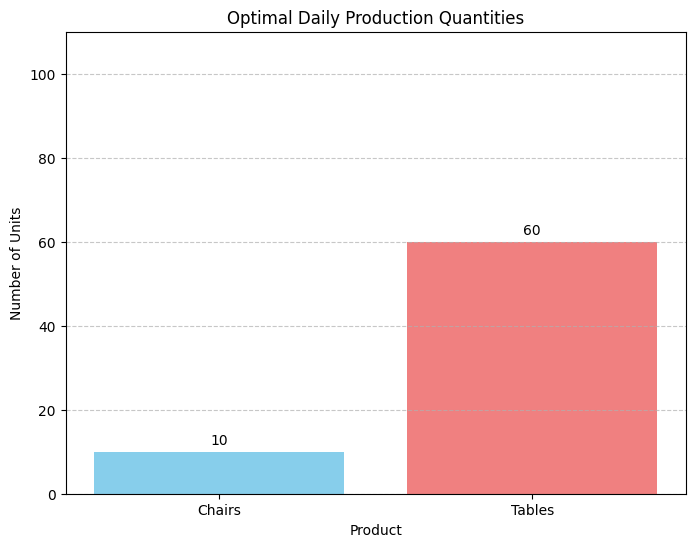

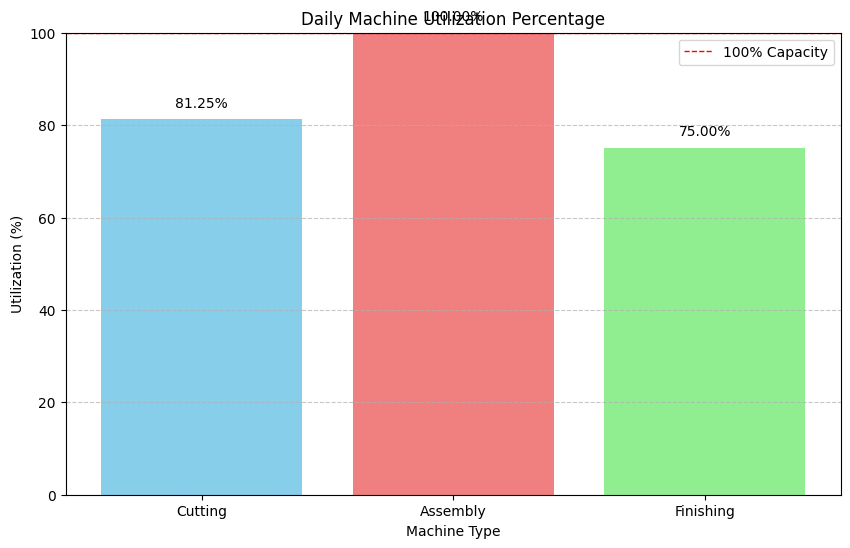

In [10]:
if model.status == GRB.OPTIMAL:
    optimal_chairs = x['Chair'].X
    optimal_tables = x['Table'].X

    # Machine utilization calculation
    machine_utilization_data = {}
    for m in machines:
        used = sum(time_per_unit[(p, m)] * x[p].X for p in products)
        machine_utilization_data[m] = (used / machine_hours_available[m]) * 100

    colors = ['skyblue', 'lightcoral', 'lightgreen']
    # ptimal Production Quantities
    plt.figure(figsize=(8, 6))
    products_produced = [optimal_chairs, optimal_tables]
    product_labels = ['Chairs', 'Tables']
    plt.bar(product_labels, products_produced, color=['skyblue', 'lightcoral'])
    plt.title('Optimal Daily Production Quantities')
    plt.xlabel('Product')
    plt.ylabel('Number of Units')
    plt.ylim(0, max(max_demand.values()) * 1.1)
    for i, v in enumerate(products_produced):
        plt.text(i, v + 1, str(int(v)), ha='center', va='bottom')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    # Machine Utilization
    plt.figure(figsize=(10, 6))
    machine_names = list(machine_utilization_data.keys())
    utilization_percentages = list(machine_utilization_data.values())

    plt.bar(machine_names, utilization_percentages, color=colors)
    plt.title('Daily Machine Utilization Percentage')
    plt.xlabel('Machine Type')
    plt.ylabel('Utilization (%)')
    plt.ylim(0, 100)
    for i, v in enumerate(utilization_percentages):
        plt.text(i, v + 2, f"{v:.2f}%", ha='center', va='bottom')
    plt.axhline(100, color='red', linestyle='--', linewidth=1, label='100% Capacity')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()



* **Production Plan:**
  The optimal production plan suggests producing **10 Chairs** and **60 Tables** per day. This combination yields the **maximum possible daily profit** of **\$16,500**, given the constraints on machine capacities and product demand.

* **Profit Maximization Strategy:**
  Despite Chairs and Tables both being profitable, the model prioritizes **Table production**, which generates more profit per unit (\$250 vs. \$150), while still respecting machine time and demand limits.

* **Demand Utilization:**

  * The **Chair production (10 units)** is **well below** the maximum daily demand of 100 units, indicating that machine capacity (especially in **Assembly**) is a tighter constraint than demand.
  * The **Table production (60 units)** exactly **matches the maximum demand**, which suggests that market demand is the limiting factor for this product.

* **Machine Utilization Overview:**

  * **Assembly Machine** is fully utilized (**100%**), making it the **bottleneck** in the production process. No additional production is possible without increasing this capacity.
  * **Cutting (81.25%)** and **Finishing (75%)** machines have **unused capacity**, indicating that the solution is primarily constrained by Assembly time.

* **Optimization Insight:**
  The model efficiently balances **profit potential**, **machine constraints**, and **market demand**, with the **Assembly machine** acting as the critical constraint that shapes the production decision.
